In [1]:
# IMPORTING LIBRARIES
from datetime import datetime 
import pandas as pd 
import matplotlib.pyplot as plt 

BUbble Chart can only be displayed between 5 PM to 7 PM IST


C:\Users\PS SANTHI\AppData\Local\Temp\ipykernel_17120\273706179.py:117: UserWarning: Glyph 2997 (\N{TAMIL LETTER VA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PS SANTHI\AppData\Local\Temp\ipykernel_17120\273706179.py:117: UserWarning: Matplotlib currently does not support Tamil natively.
  plt.tight_layout()
C:\Users\PS SANTHI\AppData\Local\Temp\ipykernel_17120\273706179.py:117: UserWarning: Glyph 2979 (\N{TAMIL LETTER NNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PS SANTHI\AppData\Local\Temp\ipykernel_17120\273706179.py:117: UserWarning: Glyph 3007 (\N{TAMIL VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PS SANTHI\AppData\Local\Temp\ipykernel_17120\273706179.py:117: UserWarning: Glyph 2965 (\N{TAMIL LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PS SANTHI\AppData\Local\Temp\ipykernel_17120\273706179.py:117: UserWarning: Glyph 2990 (\N{TAMIL LETTER MA}) missing from font(s) DejaV

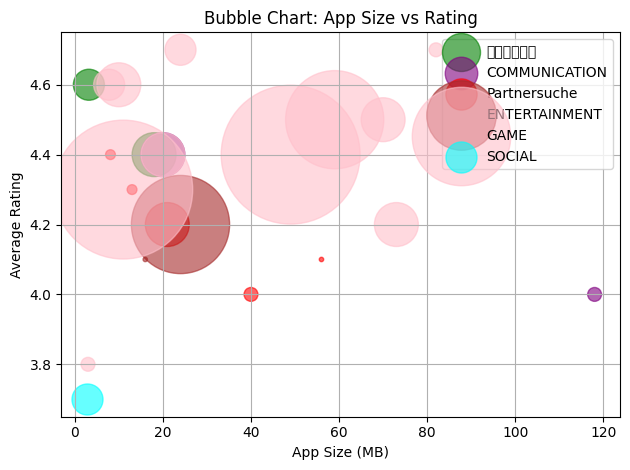

In [15]:
# GET CURRENT HOUR
current_hour = datetime.now().hour

# TIME CONDITION (5 PM to 7 PM IST)
if current_hour < 17 or current_hour >= 19:
    print("BUbble Chart can only be displayed between 5 PM to 7 PM IST")
else:
    
# LOAD DATASETS
    apps_df = pd.read_csv("E:/DATASETS/Play Store Data (1).csv")
    reviews_df = pd.read_csv("E:/DATASETS/User Reviews.csv")
    
# DATA CLEANING
    
    # Removing DUplicates
    apps_df.drop_duplicates(subset='App', inplace=True)
    
    # Clean Rating
    apps_df['Rating'] = pd.to_numeric(apps_df['Rating'], errors='coerce')
    
    # Clean Reviews
    apps_df['Reviews'] = pd.to_numeric(apps_df['Rating'], errors='coerce') 
    
    #Clean Size
    apps_df['Size'] = apps_df['Size'].str.replace('M', '', regex=False)
    apps_df['Size'] = apps_df['Size'].str.replace('k', '', regex=False)
    apps_df['Size'] = pd.to_numeric(apps_df['Size'], errors='coerce')
       
    # Clean Installs
    apps_df['Installs'] = apps_df['Installs'].str.replace(',','',regex=False)
    apps_df['Installs'] = apps_df['Installs'].str.replace('+','',regex=False)
    apps_df['Installs'] = pd.to_numeric(apps_df['Installs'], errors='coerce')
    
    # MERGE SENTIMENT DATA
    sentiment_df = reviews_df.groupby('App')['Sentiment_Subjectivity'].mean().reset_index()
    merged_df = pd.merge(apps_df,sentiment_df, on='App', how='left')
    
# REQUIRED CATEGORIES
    
    allowed_categories = [
        'GAME',
        'BEAUTY',
        'BUSINESS',
        'COMICS',
        'COMMUNICATION',
        'DATING',
        'ENTERTAINMENT',
        'SOCIAL',
        'EVENTS'
    ]
    
# APPLYING FILTERS
    
    filtered_df = merged_df[
        (merged_df['Rating'] > 3.5) &
        (merged_df['Category'].isin(allowed_categories)) &
        (merged_df['Reviews'] > 500) &
        (~merged_df['App'].str.contains('S', case=False, na=False)) &
        (merged_df['Sentiment_Subjectivity'] > 0.5) &
        (merged_df['Installs'] > 50000)
    ]
    
# CATEGORY TRANSLATIONS
    
    category_translation = {
        'BEAUTY': 'सौंदर्य',
        'BUSINESS': 'வணிகம்',
        'DATING': 'Partnersuche'
    }
    
    filtered_df['Category'] = filtered_df['Category'].replace(category_translation)
    
# BUBBLE SIZE
    
    bubble_size = filtered_df['Installs'] / 10000
    
# PLOTTING GRAPH
    plt.figure(figsize=(14,8))

# CATEGORY COLORS
colors = {
    'GAME': 'pink',
    'सौंदर्य': 'blue',
    'வணிகம்': 'green',
    'COMICS': 'orange',
    'COMMUNICATION': 'purple',
    'Partnersuche': 'red',
    'ENTERTAINMENT': 'brown',
    'SOCIAL': 'cyan',
    'EVENTS': 'gray'
}

# PLOT EACH CATEGORY
for category in filtered_df['Category'].unique():

    category_df = filtered_df[filtered_df['Category'] == category]

    plt.scatter(
        category_df['Size'],
        category_df['Rating'],
        s=category_df['Installs'] / 10000,
        alpha=0.6,
        color=colors.get(category, 'black'),
        label=category
    )

# LABELS
plt.xlabel("App Size (MB)")
plt.ylabel("Average Rating")
plt.title("Bubble Chart: App Size vs Rating")

# LEGEND
plt.legend()

# GRID
plt.grid(True)
plt.tight_layout()
# SHOW GRAPH
plt.show()
 
    
    